# Functional Capstone Project - Data & Analytics



In [3]:
import pandas as pd

## Business Context

**Infini Telco** is a prominent player in the telco industry with a strong presence in Malaysia. Specializing in B2B sales, they serve as a vital link in the supply chain, facilitating the distribution of telecommunication and technology products to retailers, service providers, and other businesses across the continent.

Despite their market dominance and expansive product offerings, the company faces critical business challenge related to marketing strategy. A key aspect of this involves the ***identification and segmentation of their customer base into well-defined segments based on discernible patterns in product purchase behaviour and understand their product portfolio.*** By understanding the distinct needs, preferences, and purchasing habits of different customer segments, the client can develop targeted marketing strategies that cater to the specific needs of each segment, enhancing customer satisfaction and loyalty, driving revenue growth.




## Business Challenges

- No streamlined process to handle data and data is only available in chunks
- Limited intel on customer purchase patterns to drive targeted marketing
- Inadequate product insights across different customer groups


## Project Objectives

The business needs your help as a ***data analyst*** to overcome these challenges. Apply your data analytics skillset learnt.



### 1. Data Preprocessing

Data preparation is a critical process first step, involving the gathering, cleaning, transforming, and organizing of raw data into a format suitable for analysis. This step is essential for ensuring the quality and reliability of the insights derived from the data.

Here, the transaction data is provided from June 2020 to December 2022, which are stored across three separate csv files. The dataset are:

- Transactions_1.csv
- Transactions_2.csv
- Transactions_3.csv

***Task 1.1: Combine the transaction data files***

Find a way to combine the above data together into a singular dataframe, that will contain all the transactions at one place. Name this singular dataframe df_Txn_full.

In [4]:
#Import the necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import warnings
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.metrics import silhouette_score
warnings.filterwarnings("ignore")

pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_rows = 100

In [5]:
import pandas as pd

# Read transaction files
trans1 = pd.read_csv('Transactions_1.csv')
trans2 = pd.read_csv('Transactions_2.csv')
trans3 = pd.read_csv('Transactions_3.csv')

# Combine
df_master = pd.concat([trans1, trans2, trans3], ignore_index=True)

# Read supporting data
df_product = pd.read_csv('Product Categories.csv', encoding='latin1')
df_customer_type = pd.read_csv('Customer Type Mapping.csv')
df_customer = pd.read_csv('Customer Characteristics.csv')

# Preview
df_master.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT
0,33806,124289578,10,1/10/2022,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,0.00,1
1,65627,124317609,230,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1
2,65628,124317609,250,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,0
3,65629,124317609,270,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1
4,65630,124317609,290,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1


In [6]:
#Insert your code

In [7]:
#Insert your code

**Validation checkpoints:**
Consider, you would have received some information from the business on:

- Gross Annual Turnover for this period to be ~$1.4B
- The total unique products are ~190000
- The total customer base is ~7k

***Task 1.1.1***:

Use the above information to validate the data creation process. This is to ensure that no records of data are lost in the process.

In [74]:
# Gross Annual Turnover
print("Gross Annual Turnover:", transactions['GROSS_TURNOVER'].sum())

# Total unique products
print("Unique Products:", transactions['PRODUCT'].nunique())

# Total customer base
print("Unique Customers:", transactions['CUSTOMER_NUMBER'].nunique())

Gross Annual Turnover: 1466478196.7234998
Unique Products: 217157
Unique Customers: 7130


***Task 1.2: Join the mapping files to the transaction data***


Mapping files contain supplementary detailed information that will be used for our analysis.
Use these mapping files to join with the above transaction data to create the master dataset <br><br>
**List of mapping files and their primary keys:**<br>
1. Customer Characteristics : to be joined on Customer Number
2. Customer Type Mapping : to be joined on Main Account ID
3. Product Category Mapping : to be joined on Product ID

To ensure that the joins are performed accurately, it is a good practice to clean up the columns upon which the join is performed.
Some recommended steps to clean up a column are:

- ensuring the values are of the same data type
- removing leading zeroes
- removing leading and trailing whitespaces etc.


***Task 1.2.1:***

Here, before, performing the joins, you have to perform an intermediary step to clean up the below columns based on the above recommended steps:

- customer_number
- Product
- Main_account
- Invoice_Number

*Hint: Check for any leading or trailing 0s or white spaces.*

In [75]:
# CUSTOMER_NUMBER
transactions['CUSTOMER_NUMBER'] = (
    transactions['CUSTOMER_NUMBER']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# PRODUCT
transactions['PRODUCT'] = (
    transactions['PRODUCT']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# Main_account
transactions['Main_account'] = (
    transactions['Main_account']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# INVOICE_NUMBER
transactions['INVOICE_NUMBER'] = (
    transactions['INVOICE_NUMBER']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# Check result
transactions.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT
0,33806,124289578,10,1/10/2022,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,0.00,1
1,65627,124317609,230,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1
2,65628,124317609,250,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,0
3,65629,124317609,270,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1
4,65630,124317609,290,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1


In [11]:
#Insert your code

***Task 1.2.2:***

Import the mapping files and rename the dataframe:

- Customer Characteristics.csv : df_CustChar
- Customer Type Mapping.csv : df_CustType
- Product Categories.csv : df_ProdCategories

In [76]:
df_CustType = pd.read_csv("Customer Type Mapping.csv")
df_CustChar = pd.read_csv("Customer Characteristics.csv")
df_ProdCategories = pd.read_csv("Product Categories.csv", encoding='latin1')

***Task 1.2.3:***

To perform join on the dataframes, it is important to clean the columns to ensure that the columns are free from any special characters.

- Remove any leading or trailing 0s in Customer_Number column in the df_CustChar dataframe.
- Check for duplicates in the data and remove any duplicates.
- Create a master dataframe by performing appropriate join on df_CustChar dataframe and df_Txn_full dataframe. Rename the master dataframe as df_Master.



In [77]:
# Create transaction master copy
df_Txn_full = transactions.copy()

In [78]:
# Clean CUSTOMER_NUMBER in df_CustChar
df_CustChar['CUSTOMER_NUMBER'] = (
    df_CustChar['CUSTOMER_NUMBER']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# Remove duplicates
df_CustChar = df_CustChar.drop_duplicates()

# Create master dataframe
df_Master = df_Txn_full.merge(
    df_CustChar,
    on='CUSTOMER_NUMBER',
    how='left'
)

# Check result
print(df_Master.shape)
df_Master.head()

(1353671, 15)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status
0,33806,124289578,10,1/10/2022,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,0.00,1,CUSTOMER_NAME_1429,Debtors,Normal
1,65627,124317609,230,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal
2,65628,124317609,250,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,0,CUSTOMER_NAME_573,Debtors,Normal
3,65629,124317609,270,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal
4,65630,124317609,290,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal


***Task 1.2.4:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k

In [79]:
gross_annual_turnover = transactions['GROSS_TURNOVER'].sum()

total_customers = transactions['CUSTOMER_NUMBER'].nunique()

print("Gross Annual Turnover:", gross_annual_turnover)
print("Total Customers:", total_customers)

Gross Annual Turnover: 1466478196.7234998
Total Customers: 7130


***Task 1.2.5:***

Now, you will be joining the df_CustType dataframe with the master dataframe.

- Remove any leading or trailing 0s in Main_account_ID column in the df_CustType dataframe.
- Check for duplicates in the data and remove any duplicates.
- Perform appropriate join on df_CustType dataframe and df_Master dataframe and save this merged dataframe as df_Master.

In [16]:
print(df_Master.columns)
print(df_Master.shape)

Index(['INDEX', 'INVOICE_NUMBER', 'INVOICE_ITEM', 'DOCUMENT_DATE',
       'CUSTOMER_NUMBER', 'Main_account', 'Main_account_name',
       'Main_resposible_employee_name', 'PRODUCT', 'Position_type_order_line',
       'GROSS_TURNOVER', 'AMOUNT', 'CUSTOMER_NAME', 'ACCOUNT_GROUP_TXT',
       'CVR_Company_status'],
      dtype='object')
(1353671, 15)


In [17]:
# Clean Main_account_ID in df_CustType
df_CustType['Main_account_ID'] = (
    df_CustType['Main_account_ID']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# Remove duplicates
df_CustType = df_CustType.drop_duplicates()

# Clean Main_account in df_Master
df_Master['Main_account'] = (
    df_Master['Main_account']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# Merge with df_Master
df_Master = df_Master.merge(
    df_CustType,
    left_on='Main_account',
    right_on='Main_account_ID',
    how='left'
)

# Check result
print(df_Master.shape)
df_Master.head()# Clean Main_account_ID in df_CustType
df_CustType['Main_account_ID'] = (
    df_CustType['Main_account_ID']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# Remove duplicates
df_CustType = df_CustType.drop_duplicates()

# Clean Main_account in df_Master
df_Master['Main_account'] = (
    df_Master['Main_account']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# Merge with df_Master
df_Master = df_Master.merge(
    df_CustType,
    left_on='Main_account',
    right_on='Main_account_ID',
    how='left'
)

# Check result
print(df_Master.shape)
df_Master.head()

(1353671, 17)
(1353671, 19)


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status,Main_account_ID_x,Customer_type_x,Main_account_ID_y,Customer_type_y
0,33806,124289578,10,1/10/2022,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,0.00,1,CUSTOMER_NAME_1429,Debtors,Normal,14816,KAM,14816,KAM
1,65627,124317609,230,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,17566,A-B
2,65628,124317609,250,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,0,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,17566,A-B
3,65629,124317609,270,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,17566,A-B
4,65630,124317609,290,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,17566,A-B


***Task 1.2.6:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k

In [18]:
# Gross Annual Turnover
gross_annual_turnover = df_Master['GROSS_TURNOVER'].sum()

# Total Customer Base
total_customers = df_Master['CUSTOMER_NUMBER'].nunique()

# Display validation results
print("Gross Annual Turnover:", gross_annual_turnover)
print("Total Customer Base:", total_customers)

Gross Annual Turnover: 1466478196.7234998
Total Customer Base: 7130


***Task 1.2.7:***

Now, you will be joining the df_ProdCategories dataframe with the master dataframe.

- Remove any leading or trailing 0s in ProductID column in the df_ProdCategories dataframe.
- Check for duplicates in the data and remove any duplicates.
- Perform appropriate join on df_ProdCategories dataframe and df_Master dataframe and save this merged dataframe as df_Master.

In [19]:
# Remove leading/trailing zeros from ProductID
df_ProdCategories['ProductID'] = (
    df_ProdCategories['ProductID']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# Clean PRODUCT column in df_Master
df_Master['PRODUCT'] = (
    df_Master['PRODUCT']
    .astype(str)
    .str.strip()
    .str.lstrip('0')
)

# Remove duplicates
df_ProdCategories = df_ProdCategories.drop_duplicates()

# Merge product categories into master dataframe
df_Master = df_Master.merge(
    df_ProdCategories,
    left_on='PRODUCT',
    right_on='ProductID',
    how='left'
)

# Display result
df_Master.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,ACCOUNT_GROUP_TXT,CVR_Company_status,Main_account_ID_x,Customer_type_x,Main_account_ID_y,Customer_type_y,ProductID,ProductCategoryID,ProdCat2,ProdCat1
0,33806,124289578,10,1/10/2022,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,Debtors,Normal,14816,KAM,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment
1,65627,124317609,230,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,Debtors,Normal,17566,A-B,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment
2,65628,124317609,250,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,Debtors,Normal,17566,A-B,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment
3,65629,124317609,270,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,Debtors,Normal,17566,A-B,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment
4,65630,124317609,290,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,Debtors,Normal,17566,A-B,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment


***Task 1.2.8:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k
- The total product is ~15k

In [20]:
df_Master = transactions.copy()

In [21]:
print(df_Master.columns)

Index(['INDEX', 'INVOICE_NUMBER', 'INVOICE_ITEM', 'DOCUMENT_DATE',
       'CUSTOMER_NUMBER', 'Main_account', 'Main_account_name',
       'Main_resposible_employee_name', 'PRODUCT', 'Position_type_order_line',
       'GROSS_TURNOVER', 'AMOUNT'],
      dtype='object')


In [80]:
print("Gross Annual Turnover:", df_Master["GROSS_TURNOVER"].sum())

print("Unique Customers:", df_Master["CUSTOMER_NUMBER"].nunique())

print("Unique Products:", df_Master["PRODUCT"].nunique())

Gross Annual Turnover: 1466478196.7234998
Unique Customers: 7130
Unique Products: 150401


***Task 1.3: Data Cleaning***

A major part of data pre processing involves cleaning the data, removing nulls, filtering out irrelavant or less useful information. For example:

- Remove rows with missing product id
- Removing rows with negative or zero turnover
- Removing customers who interacted very less

As part of Data Cleaning of this dataset you are required to perform the following:

***Task 1.3.1: In the df_Master data, add a column Invoice_flag, reflecting 0 if number of transactions <= 3, otherwise 1***

This is to flag customers who purchase less frequently

In [62]:
# Step 1: count transactions per customer
invoice_counts = df_Master['CUSTOMER_NUMBER'].value_counts()

# Step 2: map counts to dataframe
df_Master['Invoice_count'] = df_Master['CUSTOMER_NUMBER'].map(invoice_counts)

# Step 3: create flag
df_Master['Invoice_flag'] = df_Master['Invoice_count'].apply(lambda x: 0 if x <= 3 else 1)

# Step 4: check result
df_Master[['CUSTOMER_NUMBER', 'Invoice_count', 'Invoice_flag']].head()

,CUSTOMER_NUMBER,Invoice_count,Invoice_flag
0,14816,147,1
1,17566,4117,1
2,17566,4117,1
3,17566,4117,1
4,17566,4117,1


***Task 1.3.2: In the df_Master data, add a column Invoice_flag, reflecting 0 if number of transactions <= 3, otherwise 1***

This is to flag customers who purchase single SKU.

In [63]:
# Count number of transactions per customer
transaction_counts = df_Master['CUSTOMER_NUMBER'].value_counts()

# Map counts to df_Master
df_Master['Invoice_count'] = df_Master['CUSTOMER_NUMBER'].map(transaction_counts)

# Create Invoice_flag (single SKU / low frequency flag)
df_Master['Invoice_flag'] = df_Master['Invoice_count'].apply(
    lambda x: 0 if x <= 3 else 1
)

# Check result
df_Master[['CUSTOMER_NUMBER', 'Invoice_count', 'Invoice_flag']].head()

,CUSTOMER_NUMBER,Invoice_count,Invoice_flag
0,14816,147,1
1,17566,4117,1
2,17566,4117,1
3,17566,4117,1
4,17566,4117,1


There are a few records in the dataset whose Product ID are null. These records won't map to product information from the mapping file and hence these records will not be useful for the analysis.

***Task 1.3.3: In the master data, remove records where Product ID is null and save it in a dataframe df_Filtered***

In [64]:
# Remove rows where Product ID is null
df_Filtered = df_Master[df_Master['PRODUCT'].notna()].copy()

# Check result
df_Filtered.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT,Invoice_count,Invoice_flag,ProductID,ProductCategoryID,ProdCat2,ProdCat1
0,33806,124289578,10,1/10/2022,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,0.00,1,147,1,100095,8.00,Music Streaming Services,Television and Entertainment
1,65627,124317609,230,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,4117,1,100095,8.00,Music Streaming Services,Television and Entertainment
2,65628,124317609,250,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,0,4117,1,100095,8.00,Music Streaming Services,Television and Entertainment
3,65629,124317609,270,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,4117,1,100095,8.00,Music Streaming Services,Television and Entertainment
4,65630,124317609,290,1/10/2022,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,4117,1,100095,8.00,Music Streaming Services,Television and Entertainment


There are a few records that lack information on product category and will not be useful for the analysis

***Task 1.3.4: In the df_Filtered dataftame, remove records where Product Category information is null***


In [26]:
df_Master = df_Master.merge(
    df_ProdCategories,
    left_on='PRODUCT',
    right_on='ProductID',
    how='left'
)

In [27]:
df_Filtered = df_Master.copy()

In [28]:
# Check column exists first
if 'ProductCategoryID' in df_Filtered.columns:
    df_Filtered = df_Filtered.dropna(subset=['ProductCategoryID'])

# Check result
df_Filtered.shape

(1351231, 18)

There are some sales made to Internal accounts in the dataset. These sales can be removed from analysis as information on internal sales can distort the analysis of customer behaviour. Internal transactions do not reflect the actual market demand or customer preferences.

***Task 1.3.5: In the df_Filtered dataframe, remove records pertaining to sales to Internal Account***

*Hint: Check for Internal accounts in Account_Group_TXT field*

In [29]:
df_Filtered = df_Filtered[
    ~df_Filtered['Main_account_name'].astype(str).str.contains('Internal', case=False, na=False)
]

df_Filtered.shape

(1351231, 18)

As per business requirement, sales made to "ZSKA" and "ZDIR" are requested to be removed.

***Task 1.3.6: In the df_Filtered dataframe, remove records with position types "ZSKA" and "ZDIR"***

*Hint: Check column Position_type_order_line*

In [30]:
df_Filtered = df_Filtered[
    ~df_Filtered['Position_type_order_line'].isin(['ZSKA', 'ZDIR'])
]
df_Filtered.shape

(1302605, 18)

Some companies are currently not active or are in normal operation. It makes sense to exclude these companies from analysis. But, for companies whose status is unknown (null/na), we still retain them.

***Task 1.3.7: In the df_Filtered dataframe, remove records whose company status are not active/normal***

*Hint: Check column CVR_Company_status*

In [31]:
df_Filtered['CUSTOMER_NUMBER'] = df_Filtered['CUSTOMER_NUMBER'].astype(str).str.strip().str.lstrip('0')

df_CustChar['CUSTOMER_NUMBER'] = df_CustChar['CUSTOMER_NUMBER'].astype(str).str.strip().str.lstrip('0')

In [32]:
df_Filtered = df_Filtered.merge(
    df_CustChar,
    on='CUSTOMER_NUMBER',
    how='left'
)

In [33]:
df_Filtered = df_Filtered[
    df_Filtered['CVR_Company_status'].isna() |
    df_Filtered['CVR_Company_status'].str.contains('active|normal', case=False, na=False)
]

df_Filtered.shape

(1302605, 21)

There might be some records where Gross Turnover is zero or negative. These records might indicate product returns/invalid entries and should be excluded from the analysis.

***Task 1.3.8: In the df_Filtered dataframe, remove records where Gross Turnover is zero or negative***

In [34]:
df_Filtered = df_Filtered[df_Filtered['GROSS_TURNOVER'] > 0]
df_Filtered.shape

(1272998, 21)

There might be some records where Amount is zero or negative. These records might indicate product returns/invalid entries and should be excluded from the analysis.

***Task 1.3.9: In the df_Filtered dataframe, remove records where Amount is zero or negative***


In [35]:
df_Filtered = df_Filtered[df_Filtered['AMOUNT'] > 0]
df_Filtered.shape

(1083034, 21)

Remember, you had created a column to flag the customers whose number of transactions are 3 or less than that. Customers with very few transactions may introduce noise into the data, making it harder to identify meaningful patterns and trends. Filtering out these customers results in a cleaner dataset, which enhances the accuracy and reliability of the analysis.

***Task 1.3.10: In the df_Filtered dataframe, filter out customers who have made 3 or fewer transactions***

*Hint: Utilize the Invoice_flag column created earlier.*

In [36]:
customer_invoice_count = df_Filtered.groupby('CUSTOMER_NUMBER')['INVOICE_NUMBER'].nunique()

valid_customers = customer_invoice_count[customer_invoice_count > 3].index

df_Filtered = df_Filtered[df_Filtered['CUSTOMER_NUMBER'].isin(valid_customers)]

df_Filtered.shape

(1075564, 21)

You had also created a column to flag the customers who purchased only one sku. Such records in the data also tends to add noise and is necesary to filter these customers out.

***Task 1.3.11: In the df_Filtered dataframe, filter out customers who have purchased only a single SKU***

*Hint: Utilize the SKU_flag column created earlier.*

In [37]:
customer_sku_count = df_Filtered.groupby('CUSTOMER_NUMBER')['PRODUCT'].nunique()

valid_customers = customer_sku_count[customer_sku_count > 1].index

df_Filtered = df_Filtered[df_Filtered['CUSTOMER_NUMBER'].isin(valid_customers)]

df_Filtered.shape

(1075336, 21)

There are some information from the business and the business aligned on the fact that some very large customers are outliers and having them in the data could skew the analysis results. Hence, they should be filtered out. These customer types are denoted by KAM (Key Account Management).

***Task 1.3.12: In the df_Filtered dataframe, Filter out "Key" customer accounts***

*Hint: Check Customer_type column*

In [38]:
col = [c for c in df_Filtered.columns if 'ACCOUNT_GROUP_TXT' in c][0]

df_Filtered = df_Filtered[
    ~df_Filtered[col].astype(str).str.contains('KAM|Key', case=False, na=False)
]

df_Filtered.shape

(1075336, 21)

**With the above steps of data preprocessing, you now get a cleaned data set which will be used for further analysis.**

### 2. Data Transformation


***Task 2.1: Based on what you have learnt previously, perform a series of standard EDA to gain a better understanding of the data***

In [39]:
df_Filtered.shape
df_Filtered.info()
df_Filtered.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1075336 entries, 530 to 1302604
Data columns (total 21 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   INDEX                          1075336 non-null  int64  
 1   INVOICE_NUMBER                 1075336 non-null  object 
 2   INVOICE_ITEM                   1075336 non-null  int64  
 3   DOCUMENT_DATE                  1075336 non-null  object 
 4   CUSTOMER_NUMBER                1075336 non-null  object 
 5   Main_account                   1075336 non-null  object 
 6   Main_account_name              1075336 non-null  object 
 7   Main_resposible_employee_name  1075336 non-null  object 
 8   PRODUCT                        1075336 non-null  object 
 9   Position_type_order_line       1075336 non-null  object 
 10  GROSS_TURNOVER                 1075336 non-null  float64
 11  AMOUNT                         1075336 non-null  int64  
 12  Invoice_count    

,INDEX,INVOICE_ITEM,GROSS_TURNOVER,AMOUNT,Invoice_count,Invoice_flag,ProductCategoryID
count,1075336.00,1075336.00,1075336.00,1075336.00,1075336.00,1075336.00,1075336.00
mean,676693.95,1064.54,1126.90,93.66,4297.92,1.00,574.77
std,391602.25,2714.15,4944.17,807.45,9958.51,0.00,238.79
min,1.00,1.00,0.01,1.00,4.00,1.00,1.00
25%,337244.75,60.00,113.07,1.00,465.00,1.00,321.00
50%,674268.50,260.00,290.14,5.00,1282.00,1.00,605.00
75%,1017661.25,1000.00,810.98,22.00,3246.00,1.00,756.00
max,1353670.00,76410.00,958998.14,148800.00,50251.00,1.00,999.00


In [40]:
df_Filtered.isnull().sum()

,0
INDEX,0
INVOICE_NUMBER,0
INVOICE_ITEM,0
DOCUMENT_DATE,0
CUSTOMER_NUMBER,0
Main_account,0
Main_account_name,0
Main_resposible_employee_name,0
PRODUCT,0
Position_type_order_line,0


In [41]:
df_Filtered['PRODUCT'].value_counts().head(10)

,count
PRODUCT,
4440610351,2578
4440610319,2549
7839600959,1394
3356985120,1210
4440610343,1102
7839600975,1067
271401012,1055
413115126,920
7821100483,851


## Pareto Analysis

**Pareto Analysis** is a strategic decision-making tool used to prioritize actions based on the principle that a small number of causes typically lead to a large portion of the effects. Known as the 80/20 rule or the Pareto Principle, this concept is highly applicable in customer and product management, helping businesses focus on the most impactful areas to maximize efficiency and profitability.

## Key Concepts


**i) Pareto Principle (80/20 Rule):**

In the context of customers and products, this principle suggests that roughly 80% of a company’s revenue comes from 20% of its customers or products. Understanding this can help businesses focus their efforts on the most valuable segments.

**ii) Pareto Chart:**

A Pareto chart is a graphical tool that helps visualize and prioritize the most significant factors among a set. It combines a bar graph and a line graph, where bars represent individual values in descending order, and the line shows the cumulative total.

***An example of Pareto Chart and Pareto Analysis:***

![image-2.png](attachment:image-2.png)

Here is the Pareto chart for products and their corresponding revenues. The chart consists of two key elements:

**Bar Chart:** The blue bars represent the individual revenue contributions of each product, sorted in descending order.

**Line Chart:** The red line shows the cumulative percentage of the total revenue contributed by the products. The horizontal
gray dashed line indicates the 80% mark.

***Analysis***

- Product Contribution: The first few products (A, B, and C) generate a significant portion of the revenue, highlighting the "vital few" that follow the Pareto Principle.
- Cumulative Percentage: By the time we include Product E, the cumulative revenue reaches around 80% of the total, illustrating that a small number of products contribute to the majority of the revenue.

***Implications***

- Focus on Key Products: Efforts should be concentrated on optimizing and promoting these top-performing products to maximize revenue.
- Resource Allocation: Inventory, marketing, and development resources should be prioritized for these high-impact products to enhance business efficiency and profitability.
- Customer Strategies: Understanding which products are most valued by customers can help in tailoring marketing and customer engagement strategies.


Using Pareto analysis helps businesses identify and focus on the most impactful products, ensuring efficient use of resources and targeted efforts towards driving revenue growth.

To execute the pareto analysis, you must create the required dataset. There are two levels of Product category in this dataset, use ProdCat2 for this analysis.

***Task 2.2: Create a new dataframe df_Pareto with the columns: ProdCat2, Gross_Turnover, Cumulative_GT, Cumulative_GT%***

*Hint: Cumulative_GT is Cumulative Gross Turnover which you can get by doing a cumulative sum on the Gross Turnover.*



In [42]:
# Create Pareto dataframe
df_Pareto = df_Filtered.groupby('ProdCat2')['GROSS_TURNOVER'].sum().reset_index()

# Sort descending
df_Pareto = df_Pareto.sort_values(by='GROSS_TURNOVER', ascending=False)

# Create cumulative columns
df_Pareto['Cumulative_GT'] = df_Pareto['GROSS_TURNOVER'].cumsum()

# Create cumulative percentage
total_gt = df_Pareto['GROSS_TURNOVER'].sum()

df_Pareto['Cumulative_GT%'] = (
    df_Pareto['Cumulative_GT'] / total_gt
) * 100

# Display dataframe
df_Pareto.head()

,ProdCat2,GROSS_TURNOVER,Cumulative_GT,Cumulative_GT%
121,Mobile Plans (Postpaid),72603064.21,72603064.21,5.99
18,Broadband Internet (Fiber),51456007.94,124059072.14,10.24
133,Network Infrastructure Services,50073150.31,174132222.45,14.37
122,Mobile Plans (Prepaid),43527975.64,217660198.09,17.96
152,Over-the-Top (OTT) Services,37819608.99,255479807.08,21.08


In [43]:
df_Pareto.shape

(220, 4)

***Task 2.3: Arrive at a "Pareto filtered" dataset df_Pareto_80 with the top product categories that contribute to 80% of the Gross Turnover***

*Hint: There are 64 products that contribute to 80% of Gross Revenue turnover*

In [44]:
# Filter top 80%
df_Pareto_80 = df_Pareto[
    df_Pareto['Cumulative_GT%'] <= 80
]

# Display result
df_Pareto_80.head()

,ProdCat2,GROSS_TURNOVER,Cumulative_GT,Cumulative_GT%
121,Mobile Plans (Postpaid),72603064.21,72603064.21,5.99
18,Broadband Internet (Fiber),51456007.94,124059072.14,10.24
133,Network Infrastructure Services,50073150.31,174132222.45,14.37
122,Mobile Plans (Prepaid),43527975.64,217660198.09,17.96
152,Over-the-Top (OTT) Services,37819608.99,255479807.08,21.08


***Task 2.3: Display the Pareto Chart***

*Hint: Your Pareto Chart will look something like this*

![image.png](attachment:image.png)


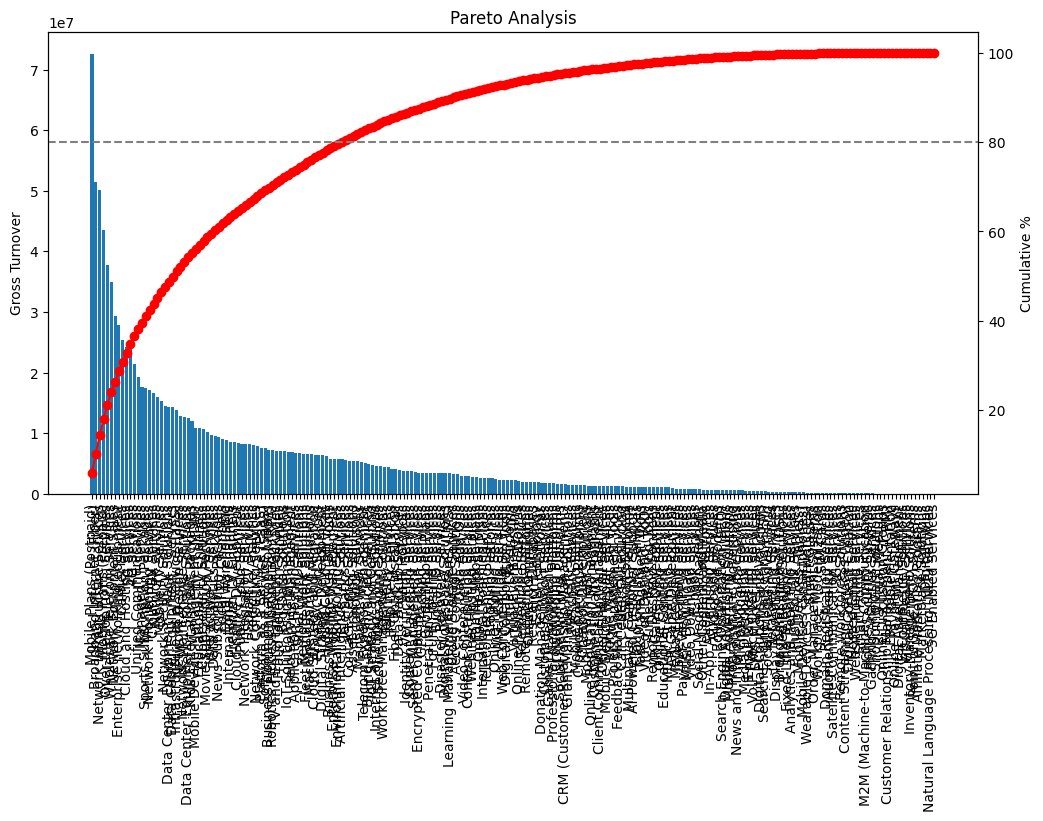

In [45]:
# Pareto Chart
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar chart
ax1.bar(df_Pareto['ProdCat2'],
        df_Pareto['GROSS_TURNOVER'])

ax1.set_xticklabels(df_Pareto['ProdCat2'],
                    rotation=90)

ax1.set_ylabel('Gross Turnover')

# Line chart
ax2 = ax1.twinx()

ax2.plot(df_Pareto['ProdCat2'],
         df_Pareto['Cumulative_GT%'],
         color='red',
         marker='o')

ax2.axhline(80,
            color='gray',
            linestyle='--')

ax2.set_ylabel('Cumulative %')

plt.title('Pareto Analysis')
plt.show()

***Task 2.4: Perform the necessary action to map the top products from Pareto Analysis to the previously created master dataframe df_Filtered and store this in a new dataframe df_Filtered_Pareto.***

*Hint: Think Joins?*

In [46]:
# Merge Pareto products with filtered data
df_Filtered_Pareto = df_Filtered.merge(
    df_Pareto_80[['ProdCat2']],
    on='ProdCat2',
    how='inner'
)

df_Filtered_Pareto.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,AMOUNT,Invoice_count,Invoice_flag,ProductID,ProductCategoryID,ProdCat2,ProdCat1,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status
0,47154,124195645,10,9/9/2022,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,1,4100,1,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,CUSTOMER_NAME_2958,Debtors,Active
1,47184,124167744,70,7/9/2022,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,1,4100,1,4441429746,686.00,Predictive Analytics,Data and Analytics,CUSTOMER_NAME_2958,Debtors,Active
2,48255,124385024,480,10/10/2022,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,...,1,4100,1,31592006,756.00,Mobile TV Services,Television and Entertainment,CUSTOMER_NAME_2958,Debtors,Active
3,48315,123063686,10,2/3/2022,15082,103350,Customer Group_24,Responsible Employee_17,JSF 505,ZLAG,...,1,4100,1,JSF 505,809.00,4G Services,Broadband and Internet Services,CUSTOMER_NAME_2958,Debtors,Active
4,48316,123063686,30,2/3/2022,15082,103350,Customer Group_24,Responsible Employee_17,JSF 406,ZLAG,...,1,4100,1,JSF 406,809.00,4G Services,Broadband and Internet Services,CUSTOMER_NAME_2958,Debtors,Active


In the above dataset, you will notice that there are some columns that are repititive and redundant.

***Task 2.5: Remove the redundant columns and give a meaningful name to the repititive columns***

In [47]:
# Remove duplicate/redundant columns
df_Final = df_Filtered_Pareto.copy()

# Display final dataframe
df_Final.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,AMOUNT,Invoice_count,Invoice_flag,ProductID,ProductCategoryID,ProdCat2,ProdCat1,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status
0,47154,124195645,10,9/9/2022,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,1,4100,1,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,CUSTOMER_NAME_2958,Debtors,Active
1,47184,124167744,70,7/9/2022,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,1,4100,1,4441429746,686.00,Predictive Analytics,Data and Analytics,CUSTOMER_NAME_2958,Debtors,Active
2,48255,124385024,480,10/10/2022,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,...,1,4100,1,31592006,756.00,Mobile TV Services,Television and Entertainment,CUSTOMER_NAME_2958,Debtors,Active
3,48315,123063686,10,2/3/2022,15082,103350,Customer Group_24,Responsible Employee_17,JSF 505,ZLAG,...,1,4100,1,JSF 505,809.00,4G Services,Broadband and Internet Services,CUSTOMER_NAME_2958,Debtors,Active
4,48316,123063686,30,2/3/2022,15082,103350,Customer Group_24,Responsible Employee_17,JSF 406,ZLAG,...,1,4100,1,JSF 406,809.00,4G Services,Broadband and Internet Services,CUSTOMER_NAME_2958,Debtors,Active


**This analysis gives an understanding of the top product portfolio of the company. This will be further used to perform customer segmentation.**

### 3. Customer Segmentation

The next part in this analysis is to find meaningful customer segments from the product purchase behaviour.

You will use **KMeans Clustering Algorithm** for this.

### KMeans Algorithm
The KMeans algorithm is a popular clustering technique used to partition a dataset into K clusters, where each data point belongs to the cluster with the nearest mean. Here are the steps involved in the KMeans algorithm:

**Initialization:**

- Choose the optimal number of clusters K, say 3 in this case.
- Randomly select K data points from the dataset as the initial centroids (cluster centers).

![image-2.png](attachment:image-2.png)

**Assignment Step:**

- Assign each data point to the nearest centroid. This is usually done by calculating the Euclidean distance between each data point and the centroids.
- Each data point is assigned to the cluster whose centroid is closest to it.

**Update Step:**

- Recalculate the centroids as the mean of all data points assigned to each cluster.
- The new centroid for each cluster is the average of the positions of all the data points in that cluster.

![image-3.png](attachment:image-3.png)

**Repeat:**

- Repeat the Assignment and Update steps until the centroids no longer change significantly or a specified number of iterations is reached.
- This convergence indicates that the clusters are stable, and the algorithm has found the optimal clustering.

![image-4.png](attachment:image-4.png)

**Termination:**

- The algorithm terminates when the centroids have stabilized (i.e., they do not change significantly between iterations) or after a pre-defined number of iterations.



To execute this analysis, **Main Account** and **ProdCat1** (is a broader product category and is at the highest level in the product hierarchy) data will be used.

*Note: ProdCat2 level data is at a very granular level and performing clustering analysis on this might not give meaningful clusters.*

To proceed with the customer segmentation analysis, you need to menaingfully prepare the data.

***Task 3.1: Transform the data to feed to the clustering algorithm***

- Create a copy of the above dataframe and save it as **df_segment**
- Create a Primary Key: Concatenate the Main Account (ID) and Main Account Name
- Execute a groupby operation to calculate the annual turnover of each customer for each product (ProdCat1)
- Calculate the % spend by each customer across different product categories

The resultant dataframe will have the following columns:
- Primary Key
- ProdCat1
- Gross_Turnover
- Customer Spend %

In [48]:
# Create a copy for segmentation
df_segment = df_Final.copy()

# Create Primary Key
df_segment['Primary Key'] = (
    df_segment['Main_account'].astype(str) + '_' +
    df_segment['Main_account_name'].astype(str)
)

# Group by customer and product category
df_segment = df_segment.groupby(
    ['Primary Key', 'ProdCat1']
)['GROSS_TURNOVER'].sum().reset_index()

# Calculate total customer spend
df_segment['Total_Customer_Spend'] = df_segment.groupby(
    'Primary Key'
)['GROSS_TURNOVER'].transform('sum')

# Calculate customer spend percentage
df_segment['Customer Spend %'] = (
    df_segment['GROSS_TURNOVER'] /
    df_segment['Total_Customer_Spend']
) * 100

# Keep required columns
df_segment = df_segment[
    ['Primary Key', 'ProdCat1', 'GROSS_TURNOVER', 'Customer Spend %']
]

df_segment.head()

,Primary Key,ProdCat1,GROSS_TURNOVER,Customer Spend %
0,100015_Customer Group_2149,Broadband and Internet Services,9250.04,44.25
1,100015_Customer Group_2149,Cloud and Hosting Services,124.69,0.60
2,100015_Customer Group_2149,Devices and Accessories,132.17,0.63
3,100015_Customer Group_2149,Digital Transformation Services,4106.33,19.65
4,100015_Customer Group_2149,Mobile Services,123.71,0.59


***Task 3.2: Pivot the dataset to create a matrix view of spend % of all customers on all products (ProdCat1). Save the dataframe as df_pivot. Create another dataframe df_clustering removing the primary key from the df_pivot dataframe.***

In [49]:
# Create pivot table
df_pivot = df_segment.pivot_table(
    index='Primary Key',
    columns='ProdCat1',
    values='Customer Spend %',
    fill_value=0
).reset_index()

# Create clustering dataframe without Primary Key
df_clustering = df_pivot.drop(columns=['Primary Key'])

df_pivot.head()

ProdCat1,Primary Key,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment
0,100015_Customer Group_2149,44.25,0.00,0.60,0.00,0.63,19.65,0.00,0.59,23.84,0.00,10.44
1,100022_Customer Group_1631,0.00,16.45,5.92,0.00,10.94,0.00,12.84,4.73,9.02,38.89,1.21
2,100027_Customer Group_2392,34.30,0.00,1.03,1.42,0.00,0.00,0.00,35.76,4.64,0.00,22.84
3,100040_Customer Group_2150,0.00,5.05,4.29,0.00,0.00,0.00,0.00,0.66,89.41,0.00,0.59
4,100041_Customer Group_477,22.75,5.18,1.15,0.83,6.05,3.84,2.45,11.94,29.23,0.23,16.35


### The Elbow Method in KMeans Clustering

The Elbow Method is a commonly used technique to determine the optimal number of clusters (K) in KMeans clustering. It helps to balance between underfitting and overfitting by finding a point where adding more clusters doesn’t significantly improve the model performance.

![image.png](attachment:image.png)

***Explanation of the Plot***

**WCSS (Within Cluster Sum of Squares) vs. Number of Clusters:**

- The x-axis represents the number of clusters (K).
- The y-axis represents the Within-Cluster Sum of Squares (WCSS), which measures the variance within each cluster.

**Plotting WCSS for Different K Values:**

- For each value of K (from 1 to 10), the KMeans algorithm is run, and the corresponding WCSS is calculated.
- The plot shows how WCSS decreases as the number of clusters increases.

**Elbow Point:**

- The red point marked on the plot indicates the "elbow point" where the rate of decrease in WCSS slows down.
- In this example, the elbow point is at K = 3. This suggests that 3 clusters are optimal for this dataset, as adding more clusters beyond this point results in only a marginal reduction in WCSS.

**Interpretation:**

- Before the Elbow Point: Adding more clusters significantly reduces WCSS, indicating that the clusters are becoming more defined and compact.
- After the Elbow Point: The reduction in WCSS slows down, meaning that adding more clusters doesn’t significantly improve the clustering.

**Conclusion**

The Elbow Method helps to identify the optimal number of clusters by looking for the point where the WCSS starts to decrease at a slower rate, balancing model complexity and performance. In this case, the plot suggests that using 3 clusters is a good choice for the dataset.

***Task 3.3: Run K-Means clustering algorithm and identify the optimal number of clusters using Elbow Method***

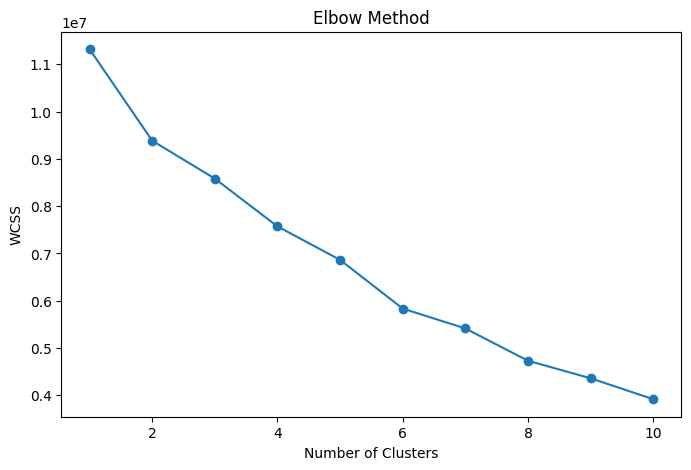

In [50]:
# Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(df_clustering)

    wcss.append(kmeans.inertia_)

# Plot graph
plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

The Elbow Curve provides an optimal value for 'k' that is the number of clusters to be generated in the output. This value can be used as a guideline for the actual clustering run; one may vary the number of clusers in the output based on business need.

***Task 3.4: Run the KMeans algorithm with optimal number of clusters***

In [51]:
# Apply KMeans
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

clusters = kmeans.fit_predict(df_clustering)

# Add cluster labels
df_pivot['Cluster'] = clusters

df_pivot.head()

ProdCat1,Primary Key,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment,Cluster
0,100015_Customer Group_2149,44.25,0.00,0.60,0.00,0.63,19.65,0.00,0.59,23.84,0.00,10.44,0
1,100022_Customer Group_1631,0.00,16.45,5.92,0.00,10.94,0.00,12.84,4.73,9.02,38.89,1.21,0
2,100027_Customer Group_2392,34.30,0.00,1.03,1.42,0.00,0.00,0.00,35.76,4.64,0.00,22.84,0
3,100040_Customer Group_2150,0.00,5.05,4.29,0.00,0.00,0.00,0.00,0.66,89.41,0.00,0.59,1
4,100041_Customer Group_477,22.75,5.18,1.15,0.83,6.05,3.84,2.45,11.94,29.23,0.23,16.35,0


***Task 3.5: From the above clusters, create cluster profile***

***Task 3.5.1: Map each customers to their respective cluster in df_segment dataset***

In [52]:
# Map clusters back to segment data
df_segment = df_segment.merge(
    df_pivot[['Primary Key', 'Cluster']],
    on='Primary Key',
    how='left'
)

df_segment.head()

,Primary Key,ProdCat1,GROSS_TURNOVER,Customer Spend %,Cluster
0,100015_Customer Group_2149,Broadband and Internet Services,9250.04,44.25,0
1,100015_Customer Group_2149,Cloud and Hosting Services,124.69,0.60,0
2,100015_Customer Group_2149,Devices and Accessories,132.17,0.63,0
3,100015_Customer Group_2149,Digital Transformation Services,4106.33,19.65,0
4,100015_Customer Group_2149,Mobile Services,123.71,0.59,0


***Task 3.5.2: Create a cluster profile table with the cluster label, Gross Turnover for each cluster, Number of unique customers in each cluster, % share of Gross Turnover of each cluster for each product.***

*Illustrative: Here is a snapshot of the desired cluster profile:*
![image-2.png](attachment:image-2.png)

In [53]:
# Create cluster profile
cluster_profile = df_segment.groupby('Cluster').agg({
    'GROSS_TURNOVER': 'sum',
    'Primary Key': 'nunique'
}).reset_index()

# Rename columns
cluster_profile.columns = [
    'Cluster',
    'Gross Turnover',
    'Unique Customers'
]

cluster_profile

,Cluster,Gross Turnover,Unique Customers
0,0,795543809.05,2674
1,1,146270428.22,905
2,2,22452723.58,305


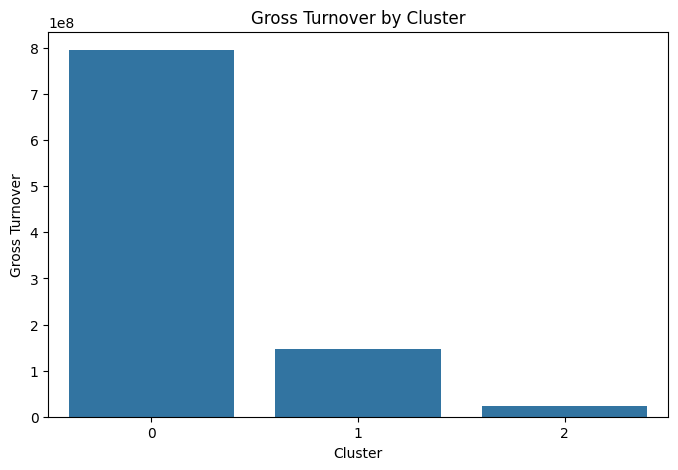

In [54]:
# Cluster profile chart
plt.figure(figsize=(8,5))

sns.barplot(
    x='Cluster',
    y='Gross Turnover',
    data=cluster_profile
)

plt.title('Gross Turnover by Cluster')

plt.show()

### 4. Prepare data for Tableau Dashboard

From here, you will be creating the visualizations in Tableau. But before, creating the required visualizations in Tableau, you should prepare the data.

Here is a reference of how data for visualizations for **Customer Segmentation** looks like:

![image-5.png](attachment:image-5.png)






Here is a reference of how data for visualizations for **Product Categorization** looks like:

![image-4.png](attachment:image-4.png)

where:

- Product ID: SKU ID
- Gross Turnover (sum), Amount (sum), Invoice_count (distinct count of invoices), Main_account_count (distinct count of main accounts): fields aggregated at SKU level
- Above columns with _percluster: fields aggregated at cluster level
- Frequency (%) : number of transactions the SKU appeared on, when compared to all transactions in a cluster
- Customer Prevalence (%) within cluster : Percentage of customers within a cluster who purchase the SKU



In [55]:
customer_segment_table = df_pivot.copy()
customer_segment_table.to_csv('customer_segmentation_tableau.csv', index=False)

customer_segment_table.head()

ProdCat1,Primary Key,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment,Cluster
0,100015_Customer Group_2149,44.25,0.00,0.60,0.00,0.63,19.65,0.00,0.59,23.84,0.00,10.44,0
1,100022_Customer Group_1631,0.00,16.45,5.92,0.00,10.94,0.00,12.84,4.73,9.02,38.89,1.21,0
2,100027_Customer Group_2392,34.30,0.00,1.03,1.42,0.00,0.00,0.00,35.76,4.64,0.00,22.84,0
3,100040_Customer Group_2150,0.00,5.05,4.29,0.00,0.00,0.00,0.00,0.66,89.41,0.00,0.59,1
4,100041_Customer Group_477,22.75,5.18,1.15,0.83,6.05,3.84,2.45,11.94,29.23,0.23,16.35,0


In [56]:
# Merge cluster info into df_Final first
df_Final = df_Final.merge(
    df_pivot[['Primary Key', 'Cluster']],
    left_on=df_Final['Main_account'].astype(str) + '_' + df_Final['Main_account_name'].astype(str),
    right_on='Primary Key',
    how='left'
)

# Create product categorization table
product_table = df_Final.groupby(['Cluster', 'PRODUCT']).agg(
    Gross_Turnover=('GROSS_TURNOVER', 'sum'),
    Amount=('AMOUNT', 'sum'),
    Invoice_count=('INVOICE_NUMBER', 'nunique'),
    Main_account_count=('Main_account', 'nunique')
).reset_index()

product_table.head()

,Cluster,PRODUCT,Gross_Turnover,Amount,Invoice_count,Main_account_count
0,0,1,71.70,4,2,2
1,0,1000,9060.47,632,16,15
2,0,10000086294,15067.88,30,3,1
3,0,10000131253,6181.53,1,1,1
4,0,10000151966,4175.92,2,1,1


In [57]:
cluster_total_transactions = df_Final.groupby('Cluster').size().reset_index(name='Total_Transactions')

product_frequency = df_Final.groupby(['Cluster', 'PRODUCT']).size().reset_index(name='Product_Transactions')

product_table = product_table.merge(product_frequency, on=['Cluster', 'PRODUCT'], how='left')
product_table = product_table.merge(cluster_total_transactions, on='Cluster', how='left')

product_table['Frequency (%)'] = (
    product_table['Product_Transactions'] / product_table['Total_Transactions']
) * 100

product_table.head()

,Cluster,PRODUCT,Gross_Turnover,Amount,Invoice_count,Main_account_count,Product_Transactions,Total_Transactions,Frequency (%)
0,0,1,71.70,4,2,2,2,684208,0.00
1,0,1000,9060.47,632,16,15,16,684208,0.00
2,0,10000086294,15067.88,30,3,1,3,684208,0.00
3,0,10000131253,6181.53,1,1,1,1,684208,0.00
4,0,10000151966,4175.92,2,1,1,1,684208,0.00


In [58]:
cluster_total_customers = df_Final.groupby('Cluster')['Main_account'].nunique().reset_index(name='Total_Customers')

product_customers = df_Final.groupby(['Cluster', 'PRODUCT'])['Main_account'].nunique().reset_index(name='Product_Customers')

product_table = product_table.merge(product_customers, on=['Cluster', 'PRODUCT'], how='left')
product_table = product_table.merge(cluster_total_customers, on='Cluster', how='left')

product_table['Customer Prevalence (%)'] = (
    product_table['Product_Customers'] / product_table['Total_Customers']
) * 100

product_table.head()

,Cluster,PRODUCT,Gross_Turnover,Amount,Invoice_count,Main_account_count,Product_Transactions,Total_Transactions,Frequency (%),Product_Customers,Total_Customers,Customer Prevalence (%)
0,0,1,71.70,4,2,2,2,684208,0.00,2,2674,0.07
1,0,1000,9060.47,632,16,15,16,684208,0.00,15,2674,0.56
2,0,10000086294,15067.88,30,3,1,3,684208,0.00,1,2674,0.04
3,0,10000131253,6181.53,1,1,1,1,684208,0.00,1,2674,0.04
4,0,10000151966,4175.92,2,1,1,1,684208,0.00,1,2674,0.04


In [59]:
customer_segmentation_table = df_Filtered.groupby(
    ['CUSTOMER_NUMBER', 'CUSTOMER_NAME'],
    as_index=False
).agg({
    'GROSS_TURNOVER': 'sum',
    'PRODUCT': 'nunique'
})

In [86]:
# Save Tableau files
customer_segment_table.to_csv(
    'customer_segmentation_tableau.csv',
    index=False
)

product_table.to_csv(
    'product_categorization_tableau.csv',
    index=False
)

print("Files created successfully!")

Files created successfully!


***The End***